In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from datetime import datetime as dt
import itertools

%matplotlib inline

In [3]:
df = pd.read_csv('epl_final.csv')

In [4]:
df.head()

,Season,MatchDate,HomeTeam,AwayTeam,FullTimeHomeGoals,FullTimeAwayGoals,FullTimeResult,HalfTimeHomeGoals,HalfTimeAwayGoals,HalfTimeResult,...,HomeShotsOnTarget,AwayShotsOnTarget,HomeCorners,AwayCorners,HomeFouls,AwayFouls,HomeYellowCards,AwayYellowCards,HomeRedCards,AwayRedCards
0,2000/01,2000-08-19,Charlton,Man City,4,0,H,2,0,H,...,14,4,6,6,13,12,1,2,0,0
1,2000/01,2000-08-19,Chelsea,West Ham,4,2,H,1,0,H,...,10,5,7,7,19,14,1,2,0,0
2,2000/01,2000-08-19,Coventry,Middlesbrough,1,3,A,1,1,D,...,3,9,8,4,15,21,5,3,1,0
3,2000/01,2000-08-19,Derby,Southampton,2,2,D,1,2,A,...,4,6,5,8,11,13,1,1,0,0
4,2000/01,2000-08-19,Leeds,Everton,2,0,H,2,0,H,...,8,6,6,4,21,20,1,3,0,0


In [5]:
df["MatchDate"] = pd.to_datetime(df["MatchDate"])

df["Year"] = df["MatchDate"].dt.year
df["Month"] = df["MatchDate"].dt.month
df["Day"] = df["MatchDate"].dt.day

In [6]:
df.head()

,Season,MatchDate,HomeTeam,AwayTeam,FullTimeHomeGoals,FullTimeAwayGoals,FullTimeResult,HalfTimeHomeGoals,HalfTimeAwayGoals,HalfTimeResult,...,AwayCorners,HomeFouls,AwayFouls,HomeYellowCards,AwayYellowCards,HomeRedCards,AwayRedCards,Year,Month,Day
0,2000/01,2000-08-19,Charlton,Man City,4,0,H,2,0,H,...,6,13,12,1,2,0,0,2000,8,19
1,2000/01,2000-08-19,Chelsea,West Ham,4,2,H,1,0,H,...,7,19,14,1,2,0,0,2000,8,19
2,2000/01,2000-08-19,Coventry,Middlesbrough,1,3,A,1,1,D,...,4,15,21,5,3,1,0,2000,8,19
3,2000/01,2000-08-19,Derby,Southampton,2,2,D,1,2,A,...,8,11,13,1,1,0,0,2000,8,19
4,2000/01,2000-08-19,Leeds,Everton,2,0,H,2,0,H,...,4,21,20,1,3,0,0,2000,8,19


In [7]:
def rolling_team_feature(df, team_col, stat_col, window=20):
    return df.groupby(team_col)[stat_col].transform(
        lambda x: x.shift().rolling(window=window, min_periods=1).mean()
    )
df["HomeAvgGoalsScored"] = rolling_team_feature(
    df, "HomeTeam", "FullTimeHomeGoals"
)
df["AwayAvgGoalsScored"] = rolling_team_feature(
    df, "AwayTeam", "FullTimeAwayGoals"
)

df["HomeAvgGoalsConceded"] = rolling_team_feature(
    df, "HomeTeam", "FullTimeAwayGoals"
)
df["AwayAvgGoalsConceded"] = rolling_team_feature(
    df, "AwayTeam", "FullTimeHomeGoals"
)

In [8]:
df.tail()

,Season,MatchDate,HomeTeam,AwayTeam,FullTimeHomeGoals,FullTimeAwayGoals,FullTimeResult,HalfTimeHomeGoals,HalfTimeAwayGoals,HalfTimeResult,...,AwayYellowCards,HomeRedCards,AwayRedCards,Year,Month,Day,HomeAvgGoalsScored,AwayAvgGoalsScored,HomeAvgGoalsConceded,AwayAvgGoalsConceded
9375,2024/25,2025-05-04,Brentford,Man United,4,3,H,2,1,H,...,2,0,0,2025,5,4,1.9,1.10,1.65,1.35
9376,2024/25,2025-05-04,Brighton,Newcastle,1,1,D,1,0,H,...,1,0,0,2025,5,4,1.4,1.85,1.35,1.55
9377,2024/25,2025-05-04,West Ham,Tottenham,1,1,D,1,1,D,...,2,0,0,2025,5,4,1.3,1.65,1.80,1.65
9378,2024/25,2025-05-04,Chelsea,Liverpool,3,1,H,1,0,H,...,2,0,0,2025,5,4,2.0,2.30,0.90,1.30
9379,2024/25,2025-05-05,Crystal Palace,Nott'm Forest,1,1,D,0,0,D,...,8,0,0,2025,5,5,1.5,1.70,1.15,1.60


In [9]:
df["HomeWin"] = (df["FullTimeResult"] == "H").astype(int)
df["AwayWin"] = (df["FullTimeResult"] == "A").astype(int)

In [10]:
df.head()

,Season,MatchDate,HomeTeam,AwayTeam,FullTimeHomeGoals,FullTimeAwayGoals,FullTimeResult,HalfTimeHomeGoals,HalfTimeAwayGoals,HalfTimeResult,...,AwayRedCards,Year,Month,Day,HomeAvgGoalsScored,AwayAvgGoalsScored,HomeAvgGoalsConceded,AwayAvgGoalsConceded,HomeWin,AwayWin
0,2000/01,2000-08-19,Charlton,Man City,4,0,H,2,0,H,...,0,2000,8,19,NaN,NaN,NaN,NaN,1,0
1,2000/01,2000-08-19,Chelsea,West Ham,4,2,H,1,0,H,...,0,2000,8,19,NaN,NaN,NaN,NaN,1,0
2,2000/01,2000-08-19,Coventry,Middlesbrough,1,3,A,1,1,D,...,0,2000,8,19,NaN,NaN,NaN,NaN,0,1
3,2000/01,2000-08-19,Derby,Southampton,2,2,D,1,2,A,...,0,2000,8,19,NaN,NaN,NaN,NaN,0,0
4,2000/01,2000-08-19,Leeds,Everton,2,0,H,2,0,H,...,0,2000,8,19,NaN,NaN,NaN,NaN,1,0


In [11]:
df["HomeWinRate"] = rolling_team_feature(df, "HomeTeam", "HomeWin")
df["AwayWinRate"] = rolling_team_feature(df, "AwayTeam", "AwayWin")

In [12]:
df["HomeShotConversion"] = df["FullTimeHomeGoals"] / df["HomeShots"].replace(0, 1)
df["AwayShotConversion"] = df["FullTimeAwayGoals"] / df["AwayShots"].replace(0, 1)

df["HomeDisciplinary"] = df["HomeYellowCards"] + 3 * df["HomeRedCards"]
df["AwayDisciplinary"] = df["AwayYellowCards"] + 3 * df["AwayRedCards"]

In [13]:
df["MatchDayNumber"] = df.groupby("Season").cumcount() + 1

df["SeasonProgress"] = df["MatchDayNumber"] / df.groupby("Season")[
    "MatchDayNumber"
].transform("max")

In [14]:
df.head()

,Season,MatchDate,HomeTeam,AwayTeam,FullTimeHomeGoals,FullTimeAwayGoals,FullTimeResult,HalfTimeHomeGoals,HalfTimeAwayGoals,HalfTimeResult,...,HomeWin,AwayWin,HomeWinRate,AwayWinRate,HomeShotConversion,AwayShotConversion,HomeDisciplinary,AwayDisciplinary,MatchDayNumber,SeasonProgress
0,2000/01,2000-08-19,Charlton,Man City,4,0,H,2,0,H,...,1,0,NaN,NaN,0.235294,0.000000,1,2,1,0.002632
1,2000/01,2000-08-19,Chelsea,West Ham,4,2,H,1,0,H,...,1,0,NaN,NaN,0.235294,0.166667,1,2,2,0.005263
2,2000/01,2000-08-19,Coventry,Middlesbrough,1,3,A,1,1,D,...,0,1,NaN,NaN,0.166667,0.187500,8,3,3,0.007895
3,2000/01,2000-08-19,Derby,Southampton,2,2,D,1,2,A,...,0,0,NaN,NaN,0.333333,0.153846,1,1,4,0.010526
4,2000/01,2000-08-19,Leeds,Everton,2,0,H,2,0,H,...,1,0,NaN,NaN,0.117647,0.000000,1,3,5,0.013158


In [15]:
home_freq = df["HomeTeam"].value_counts(normalize=True)
away_freq = df["AwayTeam"].value_counts(normalize=True)

df["HomeTeamFreqEnc"] = df["HomeTeam"].map(home_freq)
df["AwayTeamFreqEnc"] = df["AwayTeam"].map(away_freq)

In [16]:
df.head()

,Season,MatchDate,HomeTeam,AwayTeam,FullTimeHomeGoals,FullTimeAwayGoals,FullTimeResult,HalfTimeHomeGoals,HalfTimeAwayGoals,HalfTimeResult,...,HomeWinRate,AwayWinRate,HomeShotConversion,AwayShotConversion,HomeDisciplinary,AwayDisciplinary,MatchDayNumber,SeasonProgress,HomeTeamFreqEnc,AwayTeamFreqEnc
0,2000/01,2000-08-19,Charlton,Man City,4,0,H,2,0,H,...,NaN,NaN,0.235294,0.000000,1,2,1,0.002632,0.013646,0.047974
1,2000/01,2000-08-19,Chelsea,West Ham,4,2,H,1,0,H,...,NaN,NaN,0.235294,0.166667,1,2,2,0.005263,0.050000,0.044350
2,2000/01,2000-08-19,Coventry,Middlesbrough,1,3,A,1,1,D,...,NaN,NaN,0.166667,0.187500,8,3,3,0.007895,0.002026,0.019723
3,2000/01,2000-08-19,Derby,Southampton,2,2,D,1,2,A,...,NaN,NaN,0.333333,0.153846,1,1,4,0.010526,0.006077,0.033689
4,2000/01,2000-08-19,Leeds,Everton,2,0,H,2,0,H,...,NaN,NaN,0.117647,0.000000,1,3,5,0.013158,0.013966,0.049787


In [17]:
df["GoalDifference"] = df["HomeAvgGoalsScored"] - df["AwayAvgGoalsScored"]
df["ExpectedGoalDiff"] = (df["HomeAvgGoalsScored"] - df["AwayAvgGoalsConceded"]) + (
    df["AwayAvgGoalsScored"] - df["HomeAvgGoalsConceded"]
)

In [18]:
df["FormDelta"] = df["HomeWinRate"] - df["AwayWinRate"]
df["HomeAvgShots"] = rolling_team_feature(df, "HomeTeam", "HomeShots")
df["AwayAvgShots"] = rolling_team_feature(df, "AwayTeam", "AwayShots")

In [19]:
df['ShotDifference'] = abs(df['HomeShots'] - df['AwayShots'])

df = df.sort_values(by='MatchDate')

In [20]:
df['HomeAvgGoalsConceded'] = 0.0
df['AwayAvgGoalsConceded'] = 0.0

home_conceded = df.groupby('HomeTeam')['FullTimeAwayGoals'].apply(lambda x: x.shift().expanding().mean())
away_conceded = df.groupby('AwayTeam')['FullTimeHomeGoals'].apply(lambda x: x.shift().expanding().mean())

df['HomeAvgGoalsConceded'] = home_conceded.values
df['AwayAvgGoalsConceded'] = away_conceded.values

df['DefensiveStrengthDifference'] = abs(df['HomeAvgGoalsConceded'] - df['AwayAvgGoalsConceded'])

In [21]:
df.dropna(
    subset=[
        "HomeAvgGoalsScored",
        "AwayAvgGoalsScored",
        "HomeAvgGoalsConceded",
        "AwayAvgGoalsConceded",
        "HomeWinRate",
        "AwayWinRate",
        "HomeShotConversion",
        "AwayShotConversion",
        "HomeDisciplinary",
        "AwayDisciplinary",
        "FullTimeResult",
        "ShotDifference",
        "DefensiveStrengthDifference"

    ],inplace=True
)

In [22]:
df.head()

,Season,MatchDate,HomeTeam,AwayTeam,FullTimeHomeGoals,FullTimeAwayGoals,FullTimeResult,HalfTimeHomeGoals,HalfTimeAwayGoals,HalfTimeResult,...,SeasonProgress,HomeTeamFreqEnc,AwayTeamFreqEnc,GoalDifference,ExpectedGoalDiff,FormDelta,HomeAvgShots,AwayAvgShots,ShotDifference,DefensiveStrengthDifference
26,2000/01,2000-08-26,Southampton,Liverpool,3,3,D,0,1,A,...,0.071053,0.033902,0.050213,1.0,-3.0,0.0,12.0,7.0,5,0.631579
19,2000/01,2000-08-26,Arsenal,Charlton,5,3,H,1,2,A,...,0.052632,0.049893,0.013859,2.0,-1.0,1.0,17.0,8.0,11,0.500000
20,2000/01,2000-08-26,Bradford,Leicester,0,0,D,0,0,D,...,0.055263,0.002026,0.025693,1.0,3.0,0.0,12.0,4.0,5,0.523810
21,2000/01,2000-08-26,Everton,Derby,2,2,D,2,0,H,...,0.057895,0.050213,0.006077,1.0,2.0,1.0,13.0,10.0,5,0.500000
22,2000/01,2000-08-26,Ipswich,Sunderland,1,0,H,0,0,D,...,0.060526,0.005864,0.028358,-1.0,-2.0,0.0,13.0,9.0,5,0.347826


In [23]:
features = [
    "HomeAvgGoalsScored",
    "AwayAvgGoalsScored",
    "HomeAvgGoalsConceded",
    "AwayAvgGoalsConceded",
    "HomeWinRate",
    "AwayWinRate",
    "HomeShotConversion",
    "AwayShotConversion",
    "HomeDisciplinary",
    "AwayDisciplinary",
    "SeasonProgress",
    "HomeTeamFreqEnc",
    "AwayTeamFreqEnc",
    "HomeAvgShots",
    "AwayAvgShots",
    "HomeShotsOnTarget",
    "AwayShotsOnTarget",
    "HomeCorners",
    "AwayCorners",
    "HomeFouls",
    "AwayFouls",
    "GoalDifference",
    "ExpectedGoalDiff",
    "FormDelta",
    "ShotDifference",
    "DefensiveStrengthDifference"
]
target = "FullTimeResult"

In [24]:
from sklearn.model_selection import train_test_split
X = df[features]
y = df[target]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42,stratify=y)

In [25]:
X_train.shape

(6457, 26)

In [26]:
y_train.shape

(6457,)

In [27]:
from sklearn.metrics import classification_report
from sklearn.tree import DecisionTreeClassifier
model = DecisionTreeClassifier(min_samples_split=10,min_samples_leaf=4,max_depth=10,random_state=42)  
model.fit(X_train, y_train)

print(
    "DecisionTreeClassifierModel Train Score is : ",
    model.score(X_train, y_train),
)
print(
    "DecisionTreeClassifierModel Test Score is : ",
    model.score(X_test, y_test),
)
print("----------------------------------------------------")

y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred))

DecisionTreeClassifierModel Train Score is :  0.9495121573486139
DecisionTreeClassifierModel Test Score is :  0.914378612716763
----------------------------------------------------
              precision    recall  f1-score   support

           A       0.93      0.92      0.92       819
           D       0.84      0.86      0.85       683
           H       0.94      0.94      0.94      1266

    accuracy                           0.91      2768
   macro avg       0.91      0.91      0.91      2768
weighted avg       0.91      0.91      0.91      2768



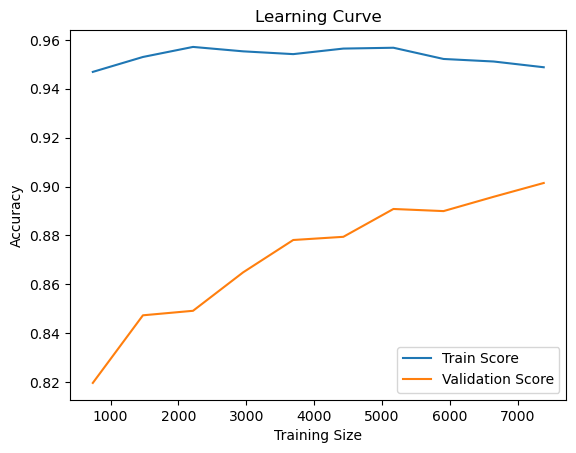

In [28]:
from sklearn.model_selection import learning_curve
train_sizes, train_scores, test_scores = learning_curve(
    model, X, y, cv=5, scoring='accuracy',
    train_sizes=np.linspace(0.1, 1.0, 10)
)

train_mean = train_scores.mean(axis=1)
test_mean = test_scores.mean(axis=1)

plt.plot(train_sizes, train_mean, label="Train Score")
plt.plot(train_sizes, test_mean, label="Validation Score")

plt.xlabel("Training Size")
plt.ylabel("Accuracy")
plt.legend()
plt.title("Learning Curve")
plt.show()

In [58]:
def predict_match(df, model, home_team, away_team, feature_list):
    
    input_df = get_team_features(df, home_team, away_team)
    
    # Fill missing columns with mean values
    for col in feature_list:
        if col not in input_df:
            input_df[col] = df[col].mean()
    
    # Ensure correct column order
    input_df = input_df[feature_list]
    
    # Fill any NaN values
    input_df = input_df.fillna(df.mean(numeric_only=True))
    
    # Predict
    pred = model.predict(input_df)[0]
    proba = model.predict_proba(input_df)[0]
    
    # Get correct class order
    classes = model.classes_
    prob_dict = dict(zip(classes, proba))
    
    return {
        "HomeTeam": home_team,
        "AwayTeam": away_team,
        "Prediction": pred,
        "AwayWinProb": prob_dict.get("A", 0),
        "DrawProb": prob_dict.get("D", 0),
        "HomeWinProb": prob_dict.get("H", 0)
    }

In [59]:
feature_list = X.columns.tolist()
result = predict_match(df, model, "Arsenal", "Chelsea",feature_list)
print(result)

{'HomeTeam': 'Arsenal', 'AwayTeam': 'Chelsea', 'Prediction': 'D', 'AwayWinProb': np.float64(0.3333333333333333), 'DrawProb': np.float64(0.6666666666666666), 'HomeWinProb': np.float64(0.0)}
